# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

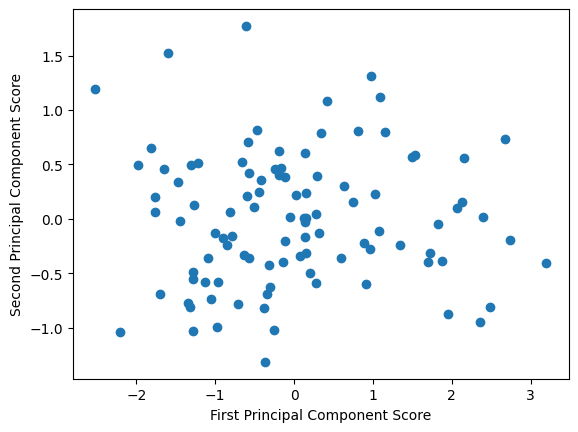

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

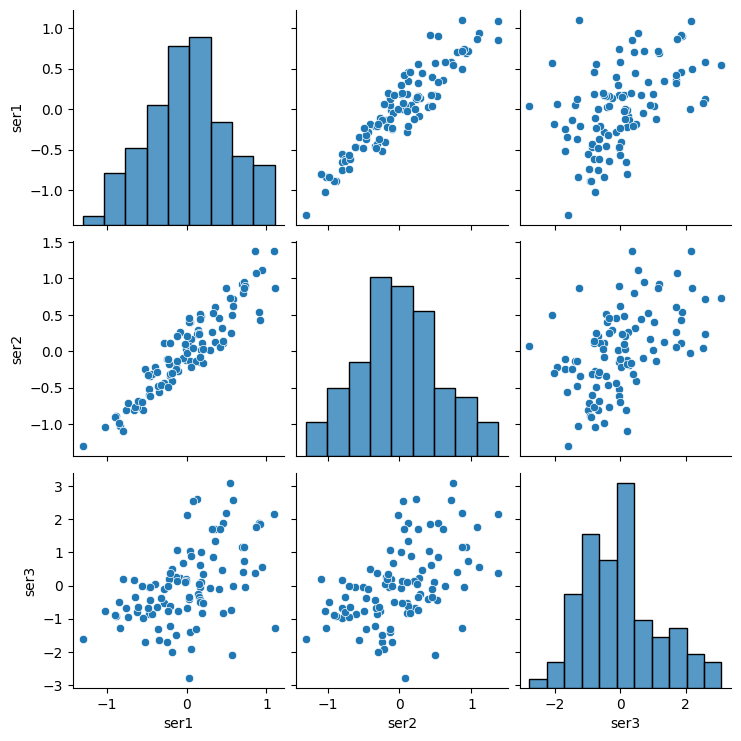

In [2]:
import seaborn as sns
sns.pairplot(df)

The three outliers in the upper left corner of the graph each have a low first principal component score (between -3 and 0) and a high second principal component score (between 1 and 2). We also know from the pair plots that series1 and series2 are highly correlated. Therefore, since the first principal component captures the direction of maximum variance, it will capture the relationship between these two series. These outliers likely have low values in series1 and series2. Next, the second principal component will capture the remaining variance in series3. Since the second principal component has a high value for these outliers, the values in the series3 is likely also to be high. The second principal component shows individidual variation of series3, whereas the first principal component shows a joint variance of series1 and series2.

One challenge with the graph is that it is not easily digestible. I had to utilize the pairplot to first understand the correlations between the series, before making judgement about the PCA results. Additionally, it would help to highlight the interesting data points with a different color to make them stick out. The advantage of this graph is that it successfully identifies three outliers.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv('C:/Users/caleb/Downloads/ppploan/ppp_over_150k.csv')

In [6]:
df

,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,...,TOTAL_PROCEED,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job
0,9547507704,2020-05-01,464,PPP,sumter coatings inc,2410 highway 15 south,sumter,UNK,29150-9662,2020-12-18,...,769358.78,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,12409.01
1,9777677704,2020-05-01,464,PPP,pleasant places inc,7684 southrail road,north charleston,UNK,29420-9000,2021-09-28,...,736927.79,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,10094.90
2,5791407702,2020-05-01,1013,PPP,boyer childrens clinic,1850 boyer ave e,seattle,UNK,98112-2922,2021-03-17,...,691355.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,9218.07
3,6223567700,2020-05-01,920,PPP,kirtley construction inc,1661 martin ranch rd,san bernardino,UNK,92407-1740,2021-10-16,...,499871.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,23803.38
4,9662437702,2020-05-01,101,PPP,aero box llc,unknown,unknown,UNK,0,2021-08-17,...,367437.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,14697.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,4395967002,2020-04-03,897,PPP,roy e paulson jr pc,102 n kenwood,casper,WY,82601-2724,2021-01-13,...,150000.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,10000.00
968528,6985647108,2020-04-14,897,PPP,sweetwater county child developmental center inc,1715 hitching post dr,green river,WY,82935-5783,2020-12-08,...,150000.00,0.0,0.033,0.967,0.0,0.0,0.0,0.0,0.0,3452.38
968529,7996438405,2021-02-12,897,PPS,electrical systems of wyoming inc,1105 adon rd,rozet,WY,82727-8465,2021-09-15,...,149998.00,2.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,29999.40
968530,9054647103,2020-04-15,897,PPP,eden life care,30 n gould street ste 4000,sheridan,WY,82801,2022-03-08,...,150000.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,21428.57


In [15]:
pivot = df.pivot_table(index="BorrowerState", columns="LoanStatus", values="ForgivenessAmount", aggfunc="sum")

Text(0.5, 1.0, 'Total ForgivenessAmount by State and Loan Status')

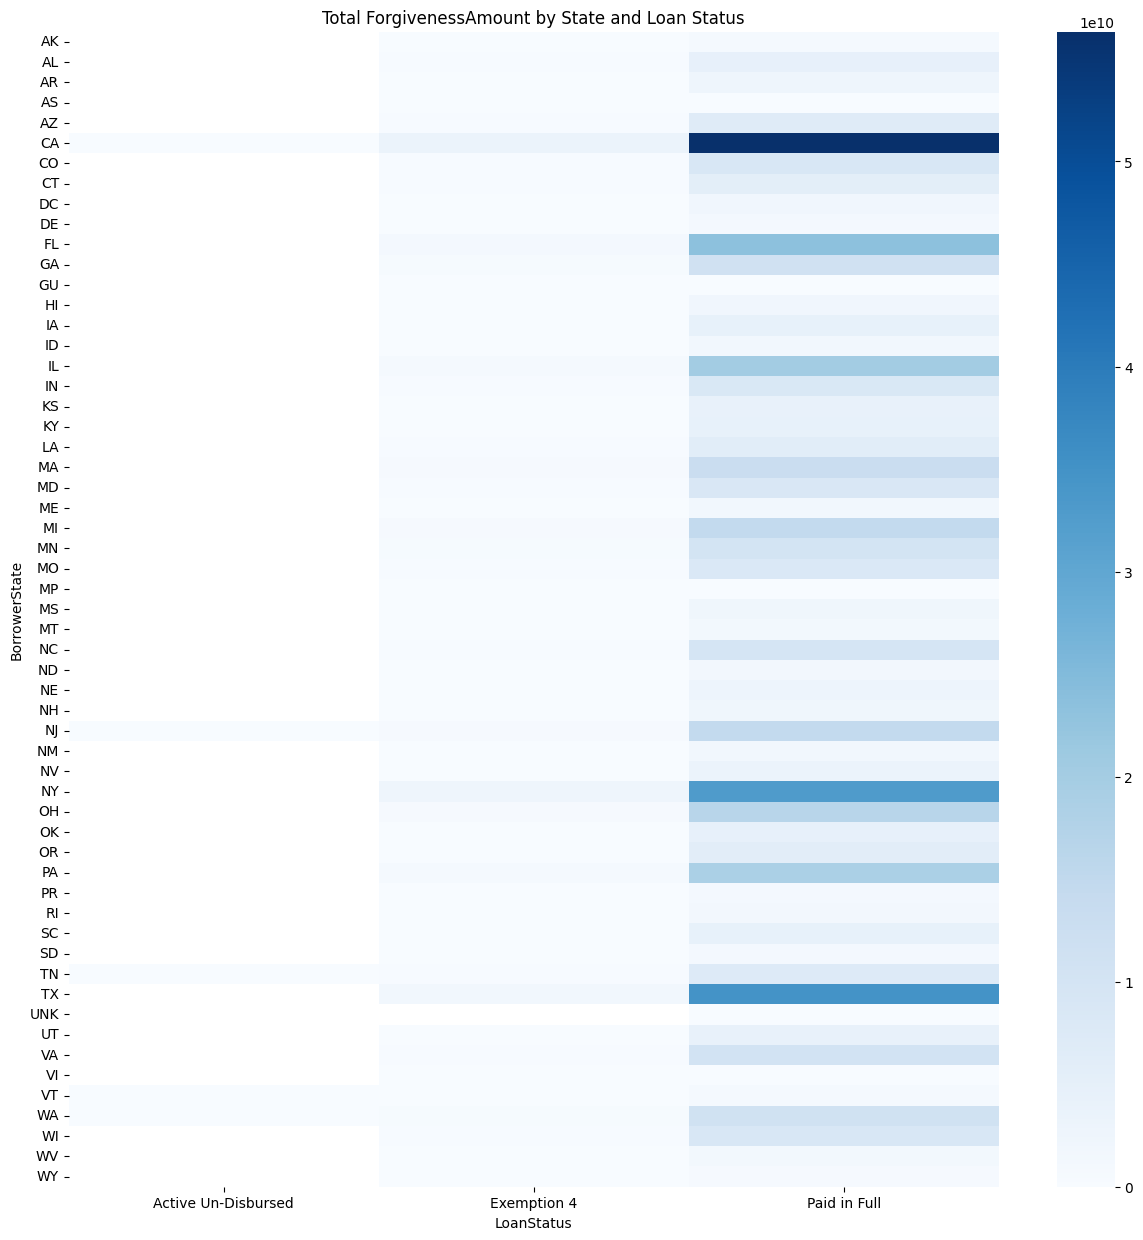

In [20]:
plt.figure(figsize=(15, 15)) # Set the desired width and height in inches
ax = sns.heatmap(pivot, cmap = "Blues")
ax.set_title("Total ForgivenessAmount by State and Loan Status")

In [27]:
df_cleaned = pd.read_csv('C:/Users/caleb/Downloads/ppploan/ppp_cleaned.csv')

Text(0, 0.5, 'PAYROLL_PROCEED')

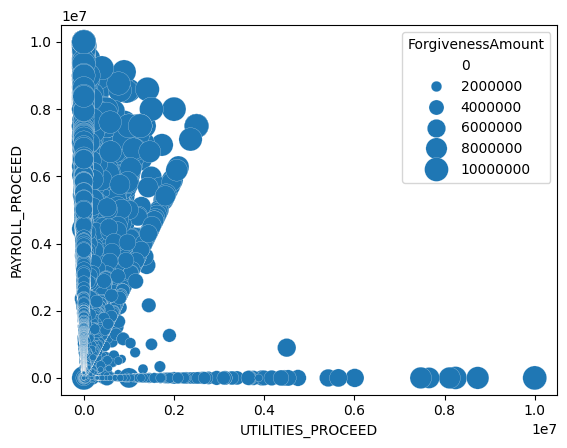

In [32]:
# 'UTILITIES_PROCEED', 'PAYROLL_PROCEED', 'MORTGAGE_INTEREST_PROCEED', 'RENT_PROCEED', 'REFINANCE_EIDL_PROCEED', 'HEALTH_CARE_PROCEED', 'DEBT_INTEREST_PROCEED'
minroot = df_cleaned['MORTGAGE_INTEREST_PROCEED'].min()
maxroot = df_cleaned['MORTGAGE_INTEREST_PROCEED'].max()
maxbubble = 300
ax = sns.scatterplot(data = df_cleaned, x = "UTILITIES_PROCEED", y = "PAYROLL_PROCEED", size = "ForgivenessAmount", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("UTILITIES_PROCEED")
ax.set_ylabel("PAYROLL_PROCEED")

In [ ]:
# 1. Determine the minimum class size
min_size = df_cleaned.groupby('Fraud')['Fraud'].count().min()
# print(f"Minimum class size: {min_size}") # Should be around 100 for this example

# 2. Group by the target column and sample 'n' items from each group
# The 'sample' method on a grouped object samples from each group automatically
balanced_df_under = df_cleaned.groupby('Fraud').sample(n=min_size, random_state=42)

# Optional: shuffle the resulting DataFrame as groupby sample preserves group order
balanced_df_under = balanced_df_under.sample(frac=1, random_state=42).reset_index(drop=True)

In [36]:
balanced_df_under

,Unnamed: 0,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,201060,0.0,8.0,1.0,24,277432.0,277432.0,33.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,11097.28,1,1588291200,-2208988800,1588291200
1,798813,0.0,46.0,1.0,24,514370.0,514370.0,11.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,19050.74,1,1591228800,-2208988800,1591228800
2,918753,0.0,50.0,1.0,60,192727.0,153334.0,44.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,17037.11,1,1588032000,-2208988800,1588032000
3,295246,0.0,13.0,2.0,24,246700.0,246700.0,13.0,1.0,1.0,...,0.0,0.000,0.0,0.0,0.0,15418.75,0,1586304000,1604534400,1607385600
4,814054,0.0,47.0,1.0,5,1795640.0,1795640.0,47.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,13011.88,1,1588550400,-2208988800,1588550400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,827885,0.0,47.0,1.0,5,583673.0,583673.0,47.0,1.0,0.0,...,0.0,0.125,0.0,0.0,0.0,3873.94,1,1588204800,-2208988800,1588204800
186,382304,1.0,19.0,1.0,60,203900.0,203900.0,19.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,10194.80,0,1612396800,-2208988800,1612396800
187,49695,0.0,5.0,2.0,24,1428400.0,1014700.0,5.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,9948.04,0,1588032000,1626739200,1628640000
188,782910,0.0,44.0,1.0,46,727000.0,727000.0,40.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,11539.68,1,1593043200,-2208988800,1593043200


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaling', StandardScaler()),
    ('pca', PCA(n_components=3))
])
pipeline.fit(balanced_df_under.drop(columns=['Fraud']), balanced_df_under['Fraud'])
pipeline

,steps,"[('scaling', ...), ('pca', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'


In [46]:
print(pipeline[1].explained_variance_ratio_)

[0.13868966 0.13317692 0.10122726]


In [47]:
print(pipeline[1].components_)

[[ 6.63463002e-02 -1.15641493e-01  7.58676499e-02 -1.87374511e-01
  -8.13649800e-02  3.59683085e-01  3.61550110e-01  2.02096206e-02
   8.77753817e-02 -4.02256630e-02 -3.18768434e-03  4.37774238e-02
   7.58676499e-02  2.13564933e-01  9.41070301e-02  3.57221936e-01
  -5.09465826e-02  8.15388626e-02 -0.00000000e+00 -9.50873473e-03
   2.16297767e-02  2.89646597e-02  1.13284159e-02  7.52907416e-02
  -5.17776527e-02  2.51230115e-02 -1.63252115e-01  3.48445904e-01
  -2.01473227e-01  3.61550264e-01 -9.67343392e-02  4.39636439e-02
  -2.86019562e-02 -5.14791433e-02  2.49906284e-02 -0.00000000e+00
  -3.27475753e-02  1.98624581e-02  1.69947549e-01 -9.63850585e-02
  -2.01809056e-01 -2.00715736e-01]
 [-1.28847027e-01 -1.38353728e-02 -1.23388286e-01  3.00326290e-01
  -3.10522053e-02  1.35014232e-01  1.62836614e-01  8.89692259e-03
   1.89806247e-02  8.59062188e-02  5.98826229e-02 -6.76114126e-02
  -1.23388286e-01  2.45326467e-01  1.34123723e-01  1.36558199e-01
   6.01856996e-02  2.15860608e-01 -0.0000

We can explain about 33 percent of the data with 3 principal components based on this PCA analysis

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [78]:
import matplotlib.pyplot as plt

In [55]:
seg_1_us = 16
seg_2_us = 7
seg_3_us = 10
seg_4_us = 10
seg_5_us = 10
seg_6_us = 32
seg_7_us = 15

seg_1_customers = 9
seg_2_customers = 10
seg_3_customers = 15
seg_4_customers = 18
seg_5_customers = 17
seg_6_customers = 20
seg_7_customers = 11

df = pd.DataFrame(
    {
        'Customer Base': ['US Population', 'Our Customers'],
        'Segment 1': [16, 9],
        'Segment 2': [7,10],
        'Segment 3': [10,15],
        'Segment 4': [10,18],
        'Segment 5': [10,17],
        'Segment 6': [32,20],
        'Segment 7': [15,11],
    }
)
df

,Customer Base,Segment 1,Segment 2,Segment 3,Segment 4,Segment 5,Segment 6,Segment 7
0,US Population,16,7,10,10,10,32,15
1,Our Customers,9,10,15,18,17,20,11


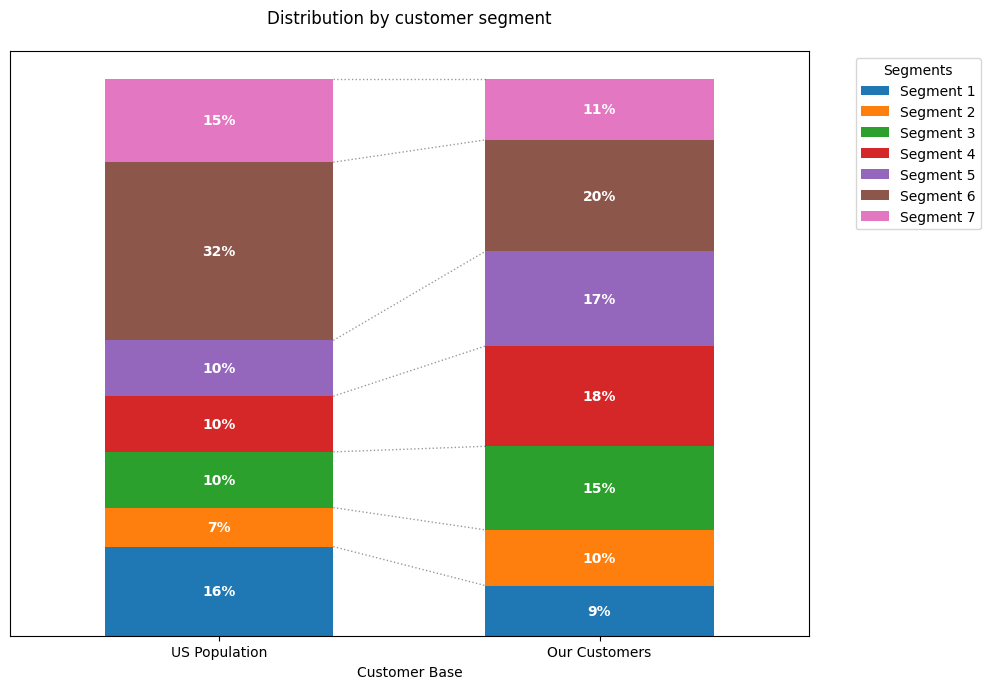

In [ ]:
# Figure 5.12 (p. 147)
ax = df.set_index('Customer Base').plot(kind='bar', stacked=True, figsize=(10, 7), width=0.6)
patches = ax.patches
num_segments = len(df.columns) - 1

for i in range(num_segments):
    # Index for Bar 1 and Bar 2 of the same segment
    idx1 = i * 2
    idx2 = i * 2 + 1
    
    rect1 = patches[idx1]
    rect2 = patches[idx2]

    # Top y-coordinate of this segment for both bars
    y1_top = rect1.get_y() + rect1.get_height()
    y2_top = rect2.get_y() + rect2.get_height()
    
    ax.plot([rect1.get_x() + rect1.get_width(), rect2.get_x()], 
            [y1_top, y2_top], 
            color='black', linestyle=':', linewidth=1, alpha=0.4)

    # --- ADD PERCENTAGE LABELS ---
    for rect in [rect1, rect2]:
        h = rect.get_height()
        if h > 0:
            ax.text(rect.get_x() + rect.get_width()/2, 
                    rect.get_y() + h/2, 
                    f'{h:.0f}%', 
                    ha='center', va='center', color='white', fontweight='bold')

plt.title('Distribution by customer segment', pad=20)
plt.xticks(rotation=0)
ax.set_yticks([]) 
plt.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()